In [110]:
# Cell 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8')

In [ ]:
# Cell 2: Load and Inspect the Dataset

# Load dataset
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)

display(df.head())

display(df.info())

Dataset Shape: (50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Columns: 300 entries, utc_timestamp to UA_load_forecast_entsoe_transparency
dtypes: float64(298), object(2)
memory usage: 115.4+ MB


None

In [ ]:
# Cell 3: Select German Electricity Demand Data (identify DE columns)

de_cols = [col for col in df.columns if "DE" in col]
print("DE columns:")
for col in de_cols:
    print(col)

DE columns:
DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation_actual
DE_amprion_load_actual_entsoe_transparency
DE_amprion_load_forecast_entsoe_transparency
DE_amprion_solar_generation_actual
DE_amprion_wind_onshore_gen

In [ ]:
# ============================================================
# Cell 4: Create Germany Electricity Demand Dataset
# Keep only the required columns
germany_df = df[['utc_timestamp', 'DE_load_actual_entsoe_transparency']].copy()

# Rename columns
germany_df.columns = ['timestamp', 'load']

# Convert timestamp to datetime
germany_df['timestamp'] = pd.to_datetime(germany_df['timestamp'])

# Sort data
germany_df = germany_df.sort_values('timestamp')

# Reset index
germany_df.reset_index(drop=True, inplace=True)

display(germany_df.head())

,timestamp,load
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0


In [ ]:
# Cell 5: Data Cleaning

print("Missing Values")

print(germany_df.isnull().sum())

# Remove missing values
germany_df = germany_df.dropna()

print("\nShape after removing missing values:")
print(germany_df.shape)

Missing Values
timestamp    0
load         0
dtype: int64

Shape after removing missing values:
(50400, 2)


In [ ]:
# Cell 6: Filter Data (January 2015 - October 2020)

germany_df = germany_df[
    (germany_df['timestamp'] >= '2015-01-01') &
    (germany_df['timestamp'] <= '2020-10-31')
]

print(germany_df.shape)

display(germany_df.head())

(50400, 2)


,timestamp,load
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0
5,2015-01-01 04:00:00+00:00,38941.0


In [ ]:
# Cell 7: Create Hourly, Daily and Weekly Datasets

# Set timestamp as index
germany_df = germany_df.set_index('timestamp')

# Hourly
hourly_df = germany_df.copy()

# Daily
daily_df = hourly_df.resample('D').mean()

# Weekly
weekly_df = hourly_df.resample('W').mean()

print("Hourly:", hourly_df.shape)
print("Daily :", daily_df.shape)
print("Weekly:", weekly_df.shape)

Hourly: (50400, 1)
Daily : (2100, 1)
Weekly: (301, 1)


In [ ]:
# Cell 8: Summary Statistics

print("Hourly Summary")
display(hourly_df.describe())

print("Daily Summary")
display(daily_df.describe())

print("Weekly Summary")
display(weekly_df.describe())

Hourly Summary


,load
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


Daily Summary


,load
count,2100.000000
mean,55492.468552
std,6601.474342
min,38952.666667
25%,50413.447917
50%,56776.916667
75%,60430.093750
max,68183.583333


Weekly Summary


,load
count,301.000000
mean,55484.350477
std,3762.742475
min,46505.309524
25%,52845.267857
50%,54858.434524
75%,58688.470238
max,63587.011905


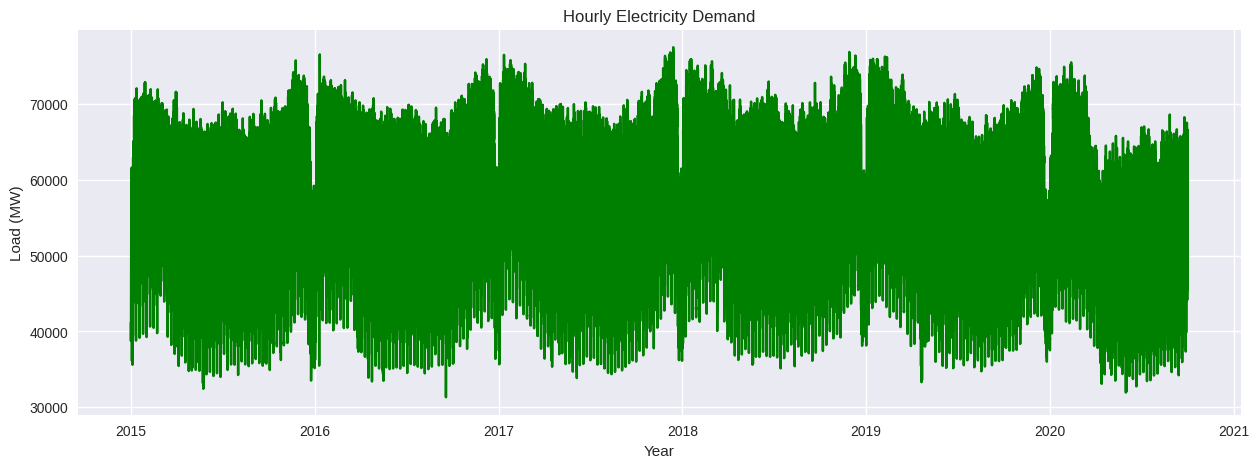

In [ ]:
# Cell 9: Hourly Electricity Demand

plt.figure(figsize=(15,5))

plt.plot(hourly_df.index, hourly_df['load'], color='green')

plt.title("Hourly Electricity Demand")

plt.xlabel("Year")

plt.ylabel("Load (MW)")

plt.show()

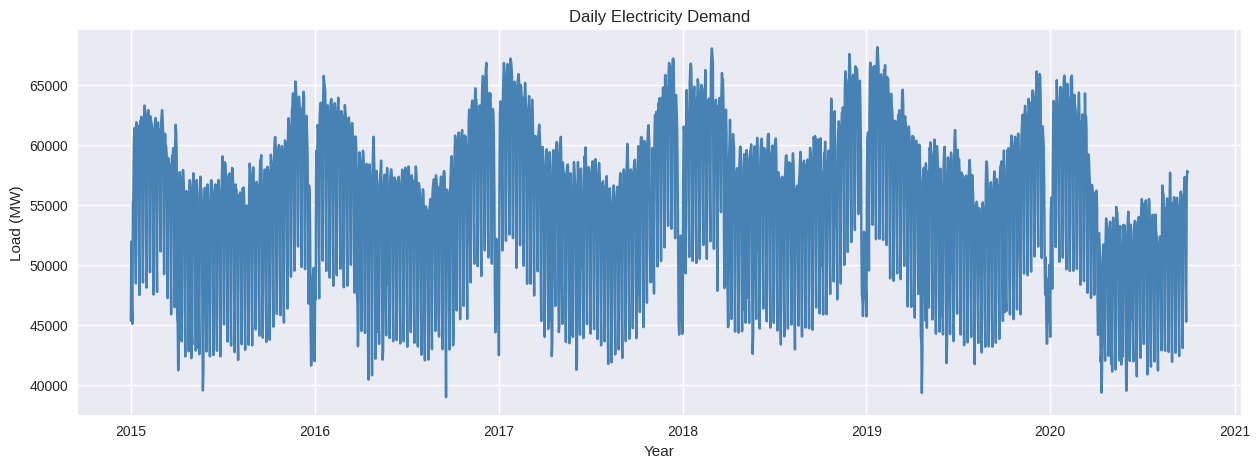

In [ ]:
# Cell 10: Daily Electricity Demand

plt.figure(figsize=(15,5))

plt.plot(daily_df.index, daily_df['load'], color='steelblue')

plt.title("Daily Electricity Demand")

plt.xlabel("Year")

plt.ylabel("Load (MW)")

plt.show()

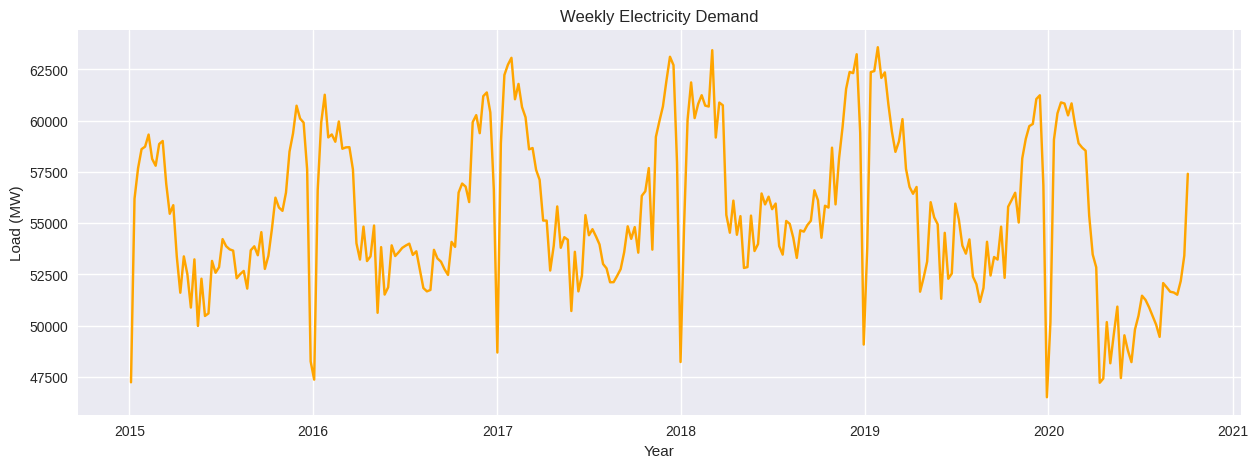

In [ ]:
# Cell 11: Weekly Electricity Demand

plt.figure(figsize=(15,5))

plt.plot(weekly_df.index, weekly_df['load'], color='orange')

plt.title("Weekly Electricity Demand")

plt.xlabel("Year")

plt.ylabel("Load (MW)")

plt.show()

Text(0, 0.5, 'Frequency')

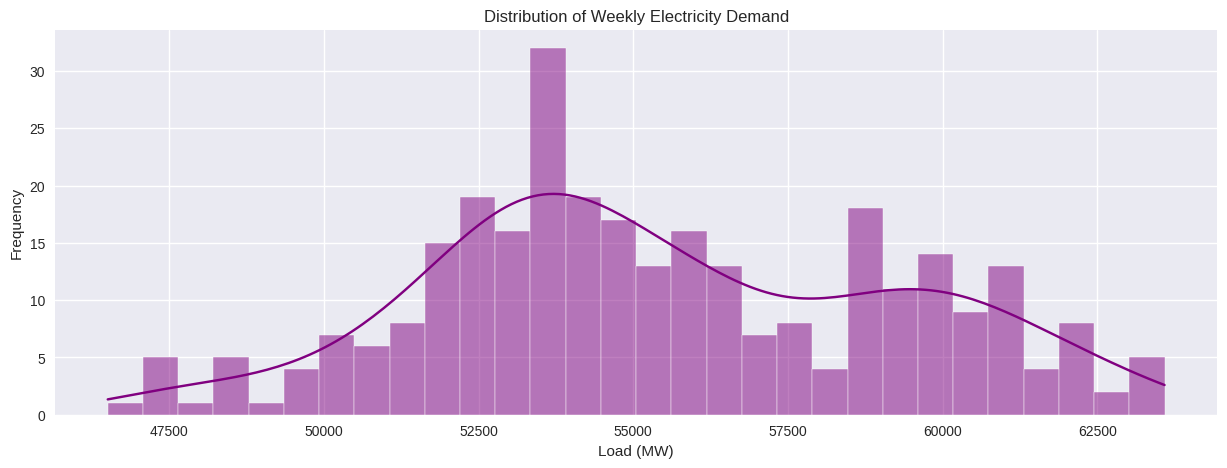

In [ ]:
# Cell 12: Distribution of Weekly Electricity Demand

plt.figure(figsize=(15,5))

sns.histplot(weekly_df['load'], bins=30, kde=True, color='purple')

plt.title("Distribution of Weekly Electricity Demand")

plt.xlabel("Load (MW)")

plt.ylabel("Frequency")

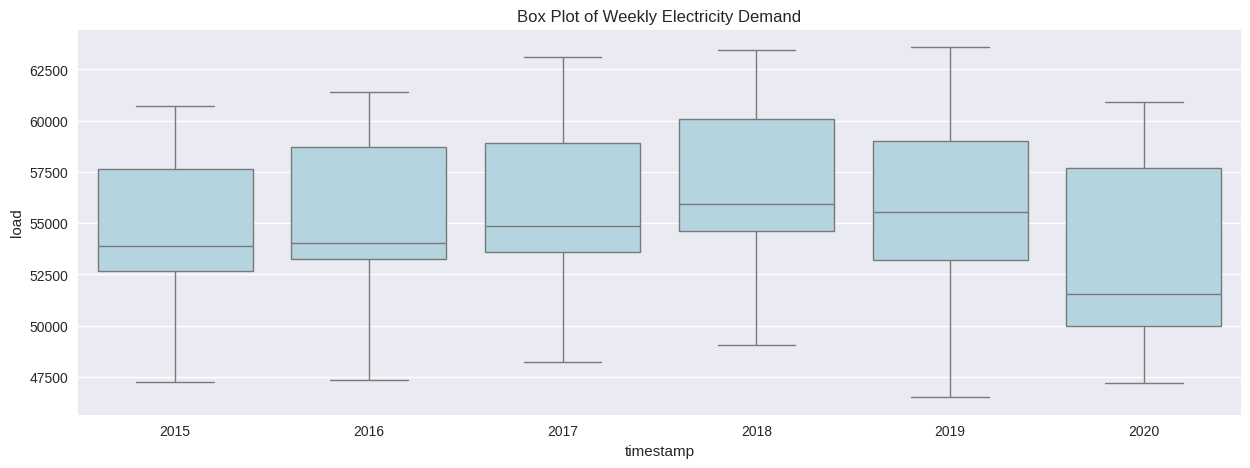

In [ ]:
# Cell 13: Box Plot

plt.figure(figsize=(15,5))

sns.boxplot(x=weekly_df.index.year, y=weekly_df['load'], color='lightblue')

plt.title("Box Plot of Weekly Electricity Demand")

plt.show()

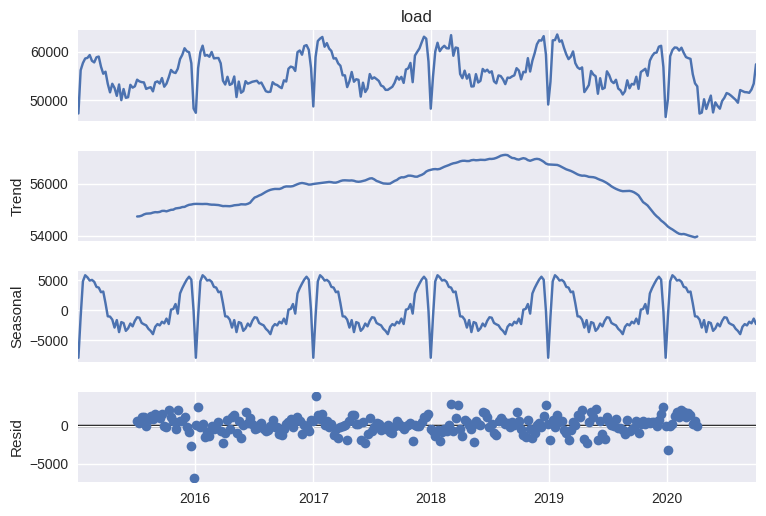

In [ ]:
# Cell 14: Seasonal Decomposition

decomposition = seasonal_decompose(
    weekly_df['load'],
    model='additive',
    period=52
)

decomposition.plot()

plt.show()

In [ ]:
# Cell 15: Time Series Components

print("Trend Component")
display(decomposition.trend.dropna().head())

print("Seasonal Component")
display(decomposition.seasonal.head())

print("Residual Component")
display(decomposition.resid.dropna().head())

Trend Component


,trend
timestamp,
2015-07-05 00:00:00+00:00,54743.165765
2015-07-12 00:00:00+00:00,54748.495936
2015-07-19 00:00:00+00:00,54774.123569
2015-07-26 00:00:00+00:00,54821.195284
2015-08-02 00:00:00+00:00,54851.053800


Seasonal Component


,seasonal
timestamp,
2015-01-04 00:00:00+00:00,-7940.673172
2015-01-11 00:00:00+00:00,-1031.066281
2015-01-18 00:00:00+00:00,4839.411821
2015-01-25 00:00:00+00:00,5850.606590
2015-02-01 00:00:00+00:00,5501.340701


Residual Component


,resid
timestamp,
2015-07-05 00:00:00+00:00,649.732398
2015-07-12 00:00:00+00:00,378.124260
2015-07-19 00:00:00+00:00,1069.608154
2015-07-26 00:00:00+00:00,1183.544544
2015-08-02 00:00:00+00:00,-18.409119


In [ ]:
# Cell 16: Augmented Dickey-Fuller (ADF) Test

result = adfuller(weekly_df['load'])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

for key, value in result[4].items():
    print(key, ":", value)

if result[1] < 0.05:
    print("\nSeries is Stationary")
else:
    print("\nSeries is Non-Stationary")

ADF Statistic : -4.0474718556784826
p-value : 0.0011813497340154512

1% : -3.4529449243622383
5% : -2.871489553425686
10% : -2.572071437887033

Series is Stationary


<Figure size 1000x500 with 0 Axes>

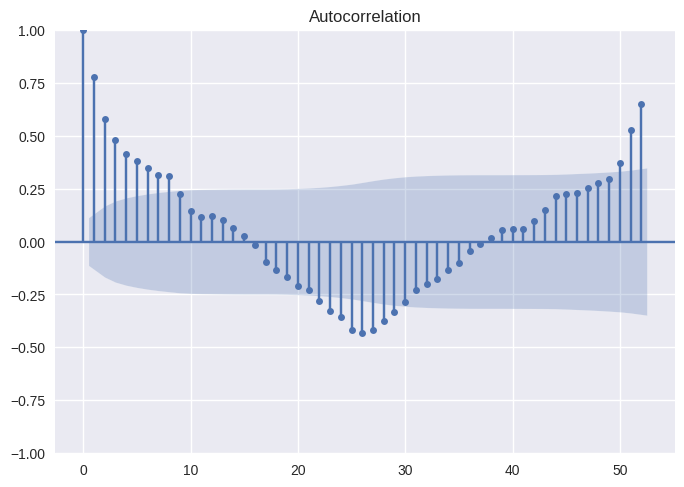

In [ ]:
# Cell 17: Autocorrelation Function (ACF)

plt.figure(figsize=(10,5))

plot_acf(weekly_df['load'], lags=52)

plt.show()

<Figure size 1000x500 with 0 Axes>

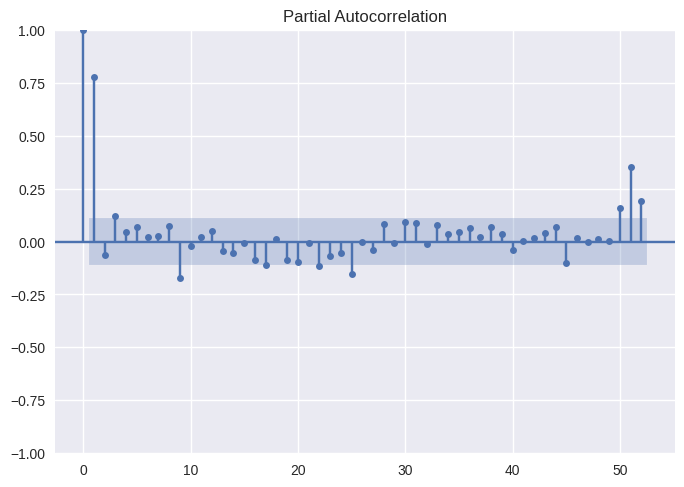

In [ ]:
# Cell 18: Partial Autocorrelation Function (PACF)

plt.figure(figsize=(10,5))

plot_pacf(weekly_df['load'], lags=52)

plt.show()

In [ ]:
# Cell 19: Train-Test Split

train_size = int(len(weekly_df) * 0.8)

train = weekly_df.iloc[:train_size]

test = weekly_df.iloc[train_size:]

print("Training Samples:", len(train))

print("Testing Samples:", len(test))

Training Samples: 240
Testing Samples: 61


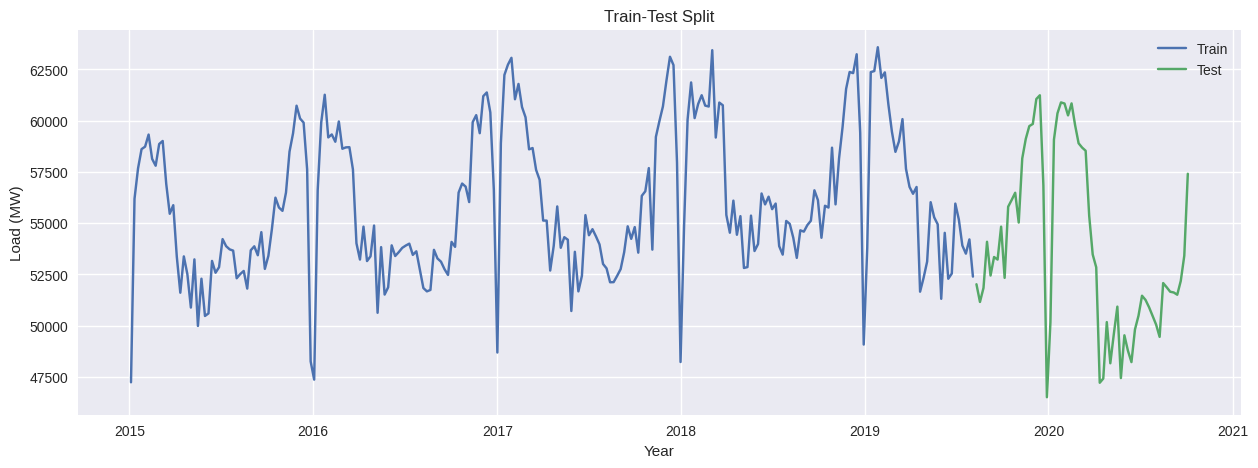

In [ ]:
# Cell 20: Train-Test Visualization

plt.figure(figsize=(15,5))

plt.plot(train.index, train['load'], label='Train')

plt.plot(test.index, test['load'], label='Test')

plt.title("Train-Test Split")

plt.xlabel("Year")

plt.ylabel("Load (MW)")

plt.legend()

plt.show()

First 5 Mean Forecast Values:


,0
timestamp,
2019-08-11 00:00:00+00:00,55901.995021
2019-08-18 00:00:00+00:00,55901.995021
2019-08-25 00:00:00+00:00,55901.995021
2019-09-01 00:00:00+00:00,55901.995021
2019-09-08 00:00:00+00:00,55901.995021


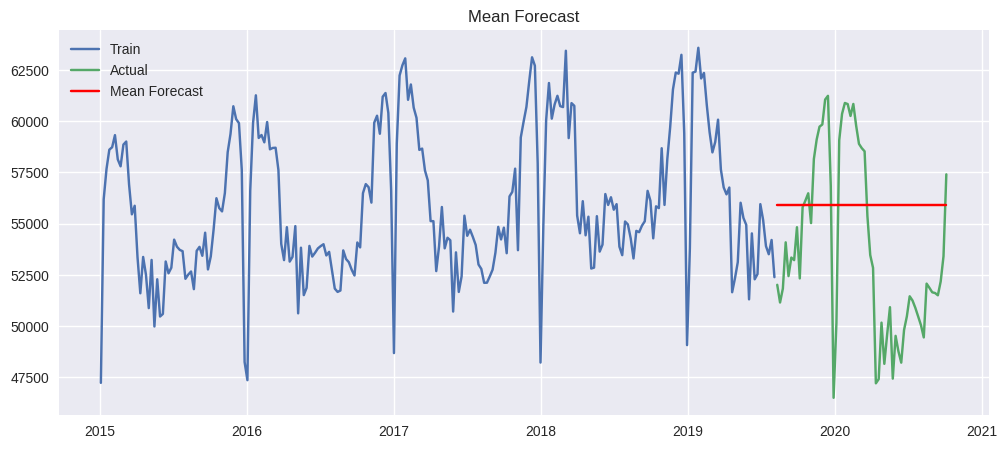

In [ ]:
# Cell 21: Mean Forecast

mean_forecast = np.repeat(train['load'].mean(), len(test))
mean_forecast = pd.Series(mean_forecast, index=test.index)

print("First 5 Mean Forecast Values:")
display(mean_forecast.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(mean_forecast, label='Mean Forecast', color='red')
plt.title("Mean Forecast")
plt.legend()
plt.show()

First 5 Naïve Forecast Values:


,0
timestamp,
2019-08-11 00:00:00+00:00,52392.10119
2019-08-18 00:00:00+00:00,52392.10119
2019-08-25 00:00:00+00:00,52392.10119
2019-09-01 00:00:00+00:00,52392.10119
2019-09-08 00:00:00+00:00,52392.10119


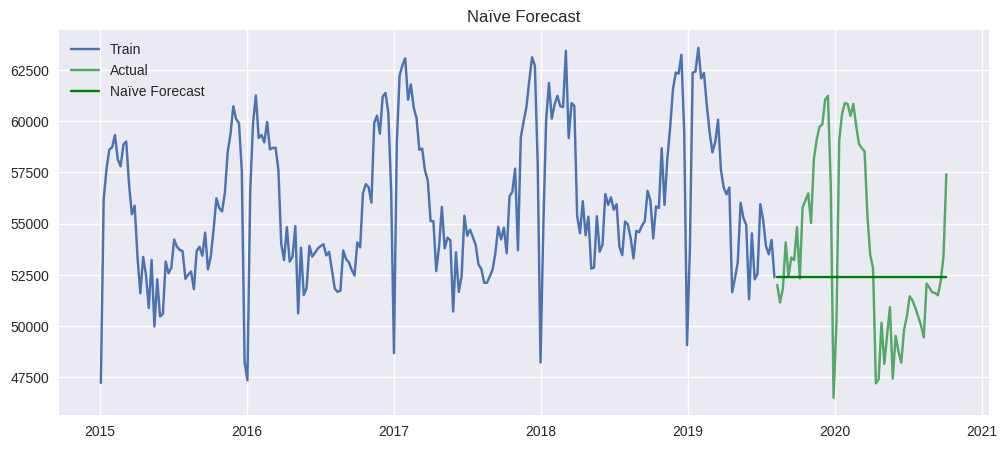

In [ ]:
# Cell 22: Naïve Forecast

naive_forecast = np.repeat(train['load'].iloc[-1], len(test))
naive_forecast = pd.Series(naive_forecast, index=test.index)

print("First 5 Naïve Forecast Values:")
display(naive_forecast.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(naive_forecast, label='Naïve Forecast', color='green')
plt.title("Naïve Forecast")
plt.legend()
plt.show()

First 5 Seasonal Naïve Forecast Values:


,0
timestamp,
2019-08-11 00:00:00+00:00,54290.315476
2019-08-18 00:00:00+00:00,53305.702381
2019-08-25 00:00:00+00:00,54650.571429
2019-09-01 00:00:00+00:00,54587.053571
2019-09-08 00:00:00+00:00,54906.511905


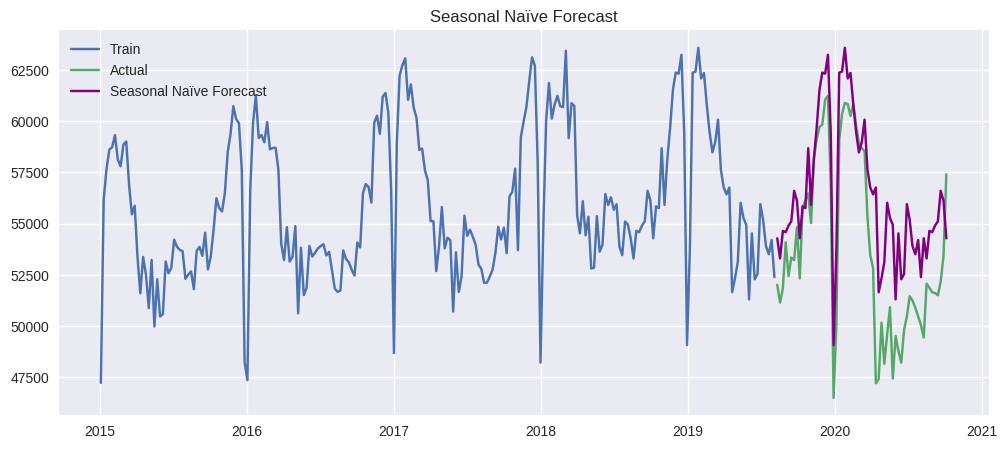

In [ ]:
# Cell 23: Seasonal Naïve Forecast

season_length = 52

seasonal_forecast = train['load'].iloc[-season_length:].values
seasonal_forecast = np.resize(seasonal_forecast, len(test))
seasonal_forecast = pd.Series(seasonal_forecast, index=test.index)

print("First 5 Seasonal Naïve Forecast Values:")
display(seasonal_forecast.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(seasonal_forecast, label='Seasonal Naïve Forecast', color='purple')
plt.title("Seasonal Naïve Forecast")
plt.legend()
plt.show()

First 5 Drift Forecast Values:


,0
timestamp,
2019-08-11 00:00:00+00:00,52413.684293
2019-08-18 00:00:00+00:00,52435.267396
2019-08-25 00:00:00+00:00,52456.850499
2019-09-01 00:00:00+00:00,52478.433602
2019-09-08 00:00:00+00:00,52500.016705


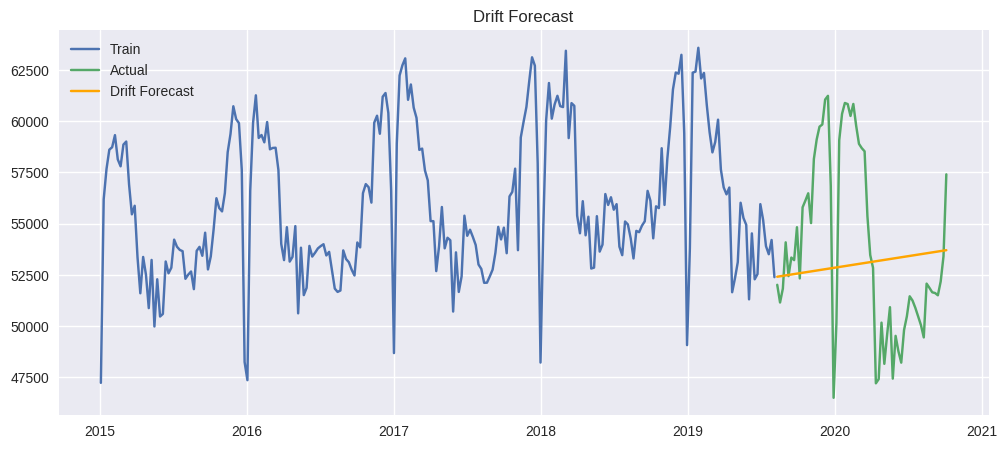

In [ ]:
# Cell 24: Drift Forecast

drift = (train['load'].iloc[-1] - train['load'].iloc[0]) / (len(train)-1)

drift_forecast = []

for h in range(1, len(test)+1):
    value = train['load'].iloc[-1] + h * drift
    drift_forecast.append(value)

drift_forecast = pd.Series(drift_forecast, index=test.index)

print("First 5 Drift Forecast Values:")
display(drift_forecast.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(drift_forecast, label='Drift Forecast', color='orange')
plt.title("Drift Forecast")
plt.legend()
plt.show()

In [ ]:
# Cell 25: Evaluate Benchmark Models

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

results = pd.DataFrame(columns=['Model','MAE','RMSE'])

models = {
    'Mean':mean_forecast,
    'Naive':naive_forecast,
    'Seasonal Naive':seasonal_forecast,
    'Drift':drift_forecast
}

for name,pred in models.items():

    mae = mean_absolute_error(test['load'],pred)

    rmse = np.sqrt(mean_squared_error(test['load'],pred))

    results.loc[len(results)] = [name,mae,rmse]

display(results)

,Model,MAE,RMSE
0,Mean,4230.102079,4742.542591
1,Naive,3597.377895,4510.480290
2,Seasonal Naive,2710.089546,3255.523670
3,Drift,3796.852789,4499.269103


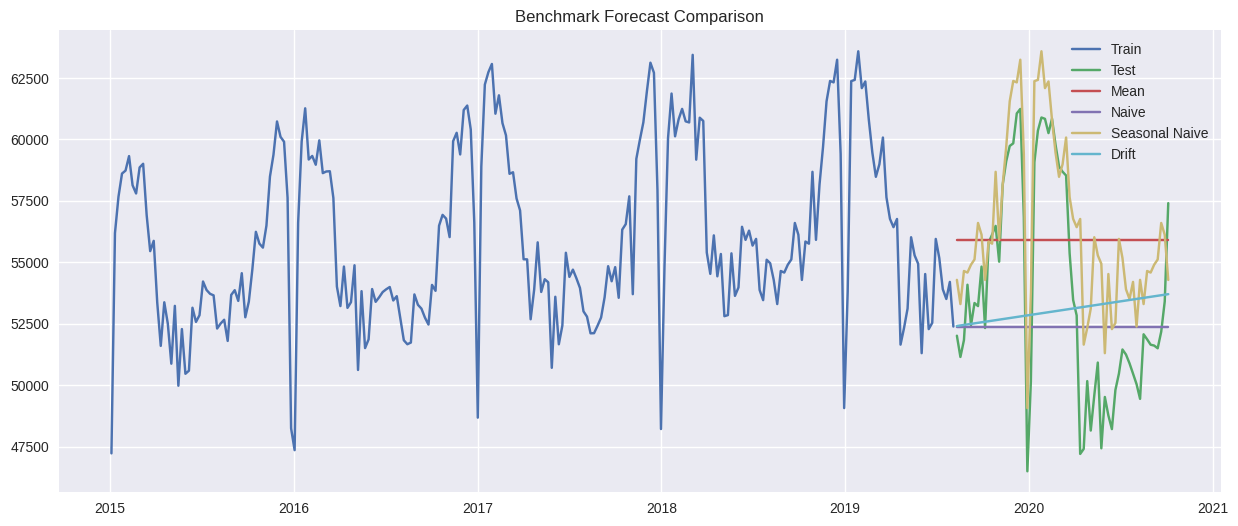

In [ ]:
# Cell 26: Compare All Benchmark Forecasts

plt.figure(figsize=(15,6))

plt.plot(train.index,train['load'],label='Train')

plt.plot(test.index,test['load'],label='Test')

plt.plot(mean_forecast,label='Mean')

plt.plot(naive_forecast,label='Naive')

plt.plot(seasonal_forecast,label='Seasonal Naive')

plt.plot(drift_forecast,label='Drift')

plt.legend()

plt.title("Benchmark Forecast Comparison")

plt.show()

In [ ]:
# Cell 27: Best Benchmark Model

best_model = results.loc[results['RMSE'].idxmin()]

print(best_model)

Model    Seasonal Naive
MAE         2710.089546
RMSE         3255.52367
Name: 2, dtype: object


In [ ]:
# Cell 28: Import Libraries for SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Cell 29: SARIMA Grid Search

best_aic = np.inf

best_order = None

best_seasonal = None

for p in range(0,3):
    for d in range(0,2):
        for q in range(0,3):

            for P in range(0,2):
                for D in range(0,2):
                    for Q in range(0,2):

                        try:

                            model = SARIMAX(
                                train['load'],
                                order=(p,d,q),
                                seasonal_order=(P,D,Q,52),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            fit = model.fit(disp=False)

                            if fit.aic < best_aic:

                                best_aic = fit.aic

                                best_order = (p,d,q)

                                best_seasonal = (P,D,Q,52)

                        except:
                            continue

print(best_order)

print(best_seasonal)

print(best_aic)

(2, 1, 1)
(1, 1, 0, 52)
2354.846861315258


In [ ]:
# Cell 30: Fit Stable SARIMA Model

sarima = SARIMAX(
    train['load'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()

print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                load   No. Observations:                  240
Model:             SARIMAX(2, 1, 1)x(1, 1, [], 52)   Log Likelihood               -1172.423
Date:                             Wed, 15 Jul 2026   AIC                           2354.847
Time:                                     21:46:20   BIC                           2369.299
Sample:                                 01-04-2015   HQIC                          2360.719
                                      - 08-04-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3111      0.131      2.372      0.018       0.054       0.568
ar.L2          0.0173      

In [ ]:
# Cell 31: Generate Forecast Using SARIMA

sarima_forecast = sarima_fit.forecast(len(test))

display(sarima_forecast.head())

,predicted_mean
2019-08-11 00:00:00+00:00,52901.617791
2019-08-18 00:00:00+00:00,52300.964488
2019-08-25 00:00:00+00:00,53726.331865
2019-09-01 00:00:00+00:00,53725.393576
2019-09-08 00:00:00+00:00,54083.438663


In [ ]:
# Cell 32: Evaluate SARIMA Model

sarima_mae = mean_absolute_error(test['load'],sarima_forecast)

sarima_rmse = np.sqrt(mean_squared_error(test['load'],sarima_forecast))

print("MAE :",sarima_mae)

print("RMSE :",sarima_rmse)

MAE : 2042.3232866210108
RMSE : 2613.5674076316573


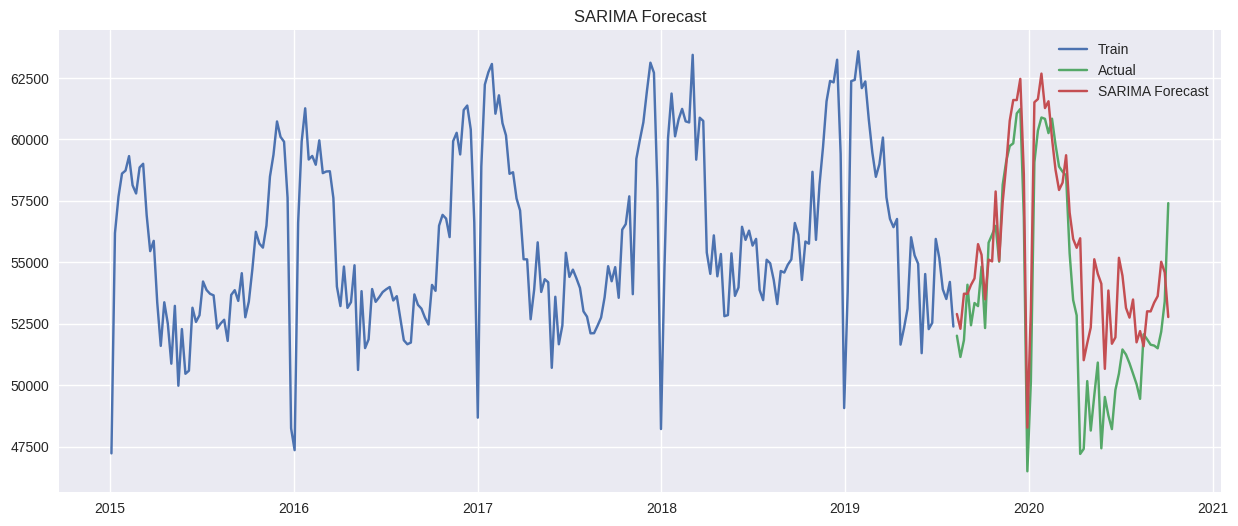

In [ ]:
# Cell 33: SARIMA Forecast Plot

plt.figure(figsize=(15,6))

plt.plot(train.index,train['load'],label='Train')

plt.plot(test.index,test['load'],label='Actual')

plt.plot(test.index,sarima_forecast,label='SARIMA Forecast')

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [ ]:
# Cell 34: Update Comparison Table

results.loc[len(results)] = [
    'SARIMA',
    sarima_mae,
    sarima_rmse
]

results = results.sort_values('RMSE')

display(results)

,Model,MAE,RMSE
4,SARIMA,2042.323287,2613.567408
2,Seasonal Naive,2710.089546,3255.523670
3,Drift,3796.852789,4499.269103
1,Naive,3597.377895,4510.480290
0,Mean,4230.102079,4742.542591


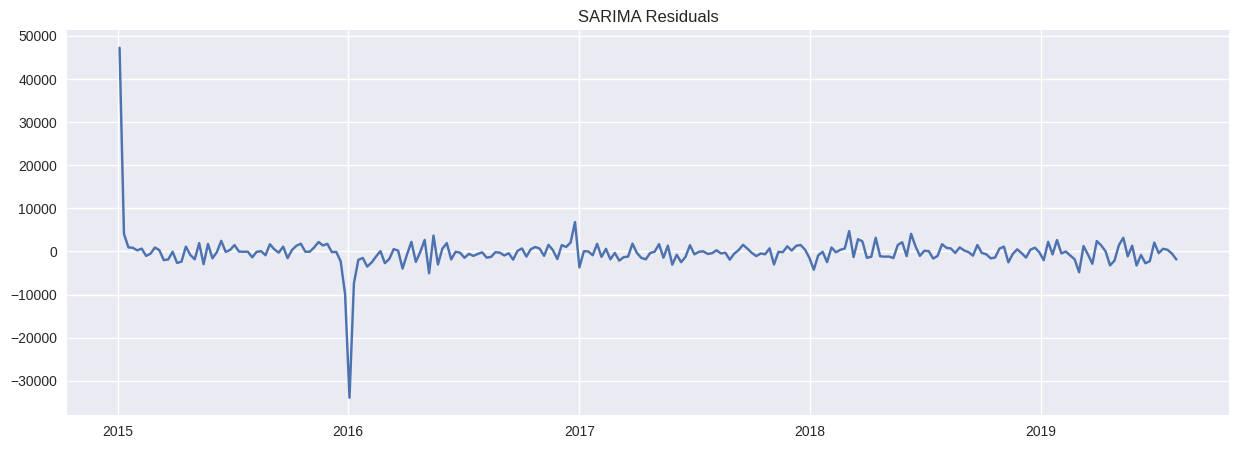

count      240.000000
mean      -202.795350
std       4185.638749
min     -33919.833268
25%      -1277.836790
50%       -169.566101
75%        859.053828
max      47233.739583
dtype: float64


In [ ]:
# Cell 35: Residual Analysis

residuals = sarima_fit.resid

plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMA Residuals")

plt.show()

print(residuals.describe())

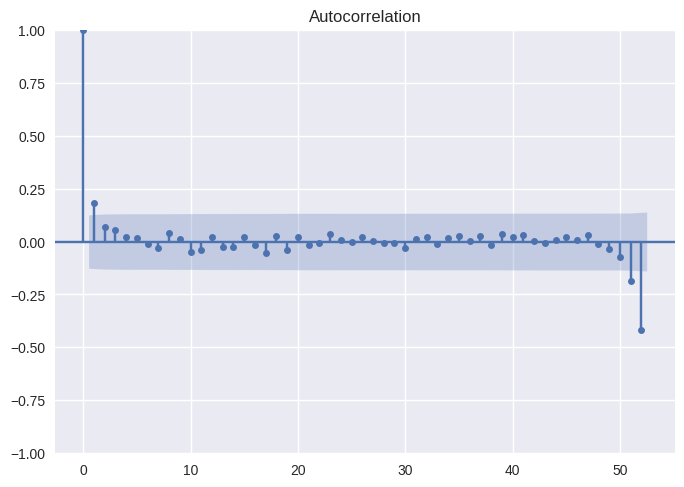

In [ ]:
# Cell 36: Residual ACF

plot_acf(residuals.dropna(),lags=52)

plt.show()

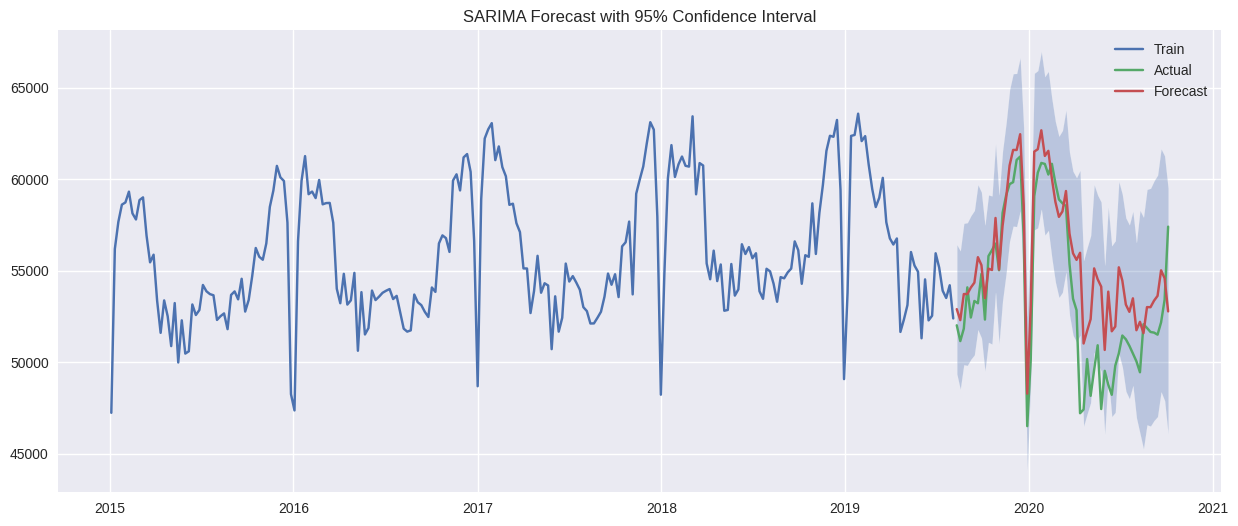

In [ ]:
# Cell 37: Forecast with Confidence Intervals

forecast = sarima_fit.get_forecast(steps=len(test))

forecast_mean = forecast.predicted_mean

conf_int = forecast.conf_int()

plt.figure(figsize=(15,6))

plt.plot(train.index,train['load'],label='Train')

plt.plot(test.index,test['load'],label='Actual')

plt.plot(test.index,forecast_mean,label='Forecast')

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()

plt.title("SARIMA Forecast with 95% Confidence Interval")

plt.show()

In [ ]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive?latitude=52.52&longitude=13.41&start_date=2015-01-01&end_date=2020-09-30&daily=temperature_2m_mean&timezone=Europe/Berlin"

response = requests.get(url)

print("Status Code:", response.status_code)
print(response.text[:500])

Status Code: 200
{"latitude":52.54833,"longitude":13.407822,"generationtime_ms":85.7234001159668,"utc_offset_seconds":7200,"timezone":"Europe/Berlin","timezone_abbreviation":"GMT+2","elevation":38.0,"daily_units":{"time":"iso8601","temperature_2m_mean":"°C"},"daily":{"time":["2015-01-01","2015-01-02","2015-01-03","2015-01-04","2015-01-05","2015-01-06","2015-01-07","2015-01-08","2015-01-09","2015-01-10","2015-01-11","2015-01-12","2015-01-13","2015-01-14","2015-01-15","2015-01-16","2015-01-17","2015-01-18","2015-0


In [ ]:
# Cell 38: Retrieve Berlin Temperature Data

import requests

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=52.52"
    "&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-09-30"
    "&daily=temperature_2m_mean"
    "&timezone=Europe/Berlin"
)

response = requests.get(url)

weather = response.json()

print(weather.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [ ]:
# Cell 39: Create Temperature Dataset

temperature_df = pd.DataFrame({
    'timestamp': weather['daily']['time'],
    'temperature': weather['daily']['temperature_2m_mean']
})

temperature_df['timestamp'] = pd.to_datetime(temperature_df['timestamp'])

temperature_df = temperature_df.set_index('timestamp')

print("Dataset Shape:", temperature_df.shape)

display(temperature_df.head())

Dataset Shape: (2100, 1)


,temperature
timestamp,
2015-01-01,2.8
2015-01-02,4.6
2015-01-03,3.9
2015-01-04,3.0
2015-01-05,2.7


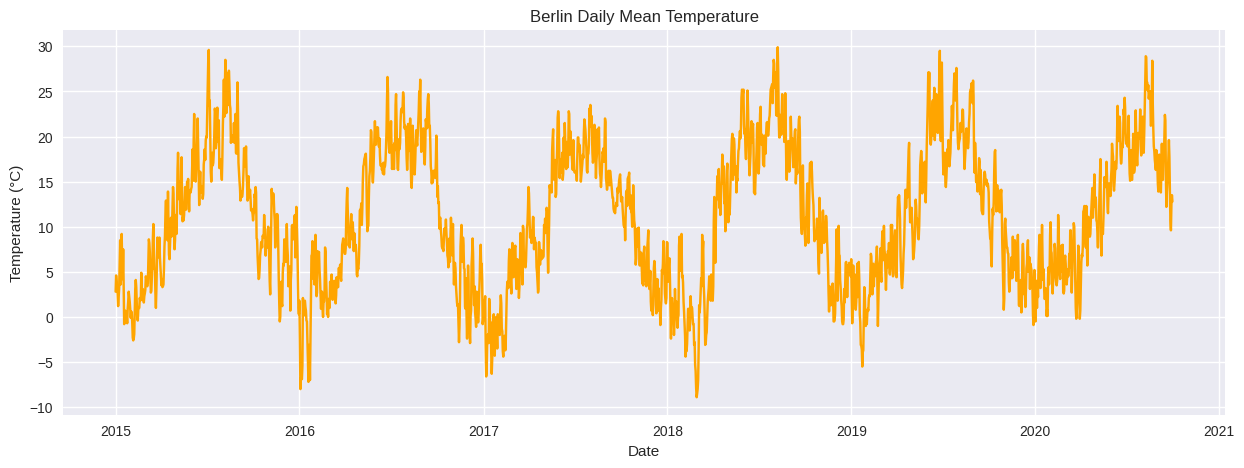

In [ ]:
# Cell 40: Berlin Temperature Time Series

plt.figure(figsize=(15,5))

plt.plot(
    temperature_df.index,
    temperature_df['temperature'],
    color='orange'
)

plt.title("Berlin Daily Mean Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.show()

In [ ]:
# Cell 41: Convert Daily Temperature to Weekly Average

weekly_df.index = weekly_df.index.tz_localize(None)
weekly_temp = temperature_df.resample('W').mean()

print("Weekly Dataset Shape:", weekly_temp.shape)

display(weekly_temp.head())

Weekly Dataset Shape: (301, 1)


,temperature
timestamp,
2015-01-04,3.575000
2015-01-11,3.885714
2015-01-18,4.900000
2015-01-25,0.028571
2015-02-01,1.414286


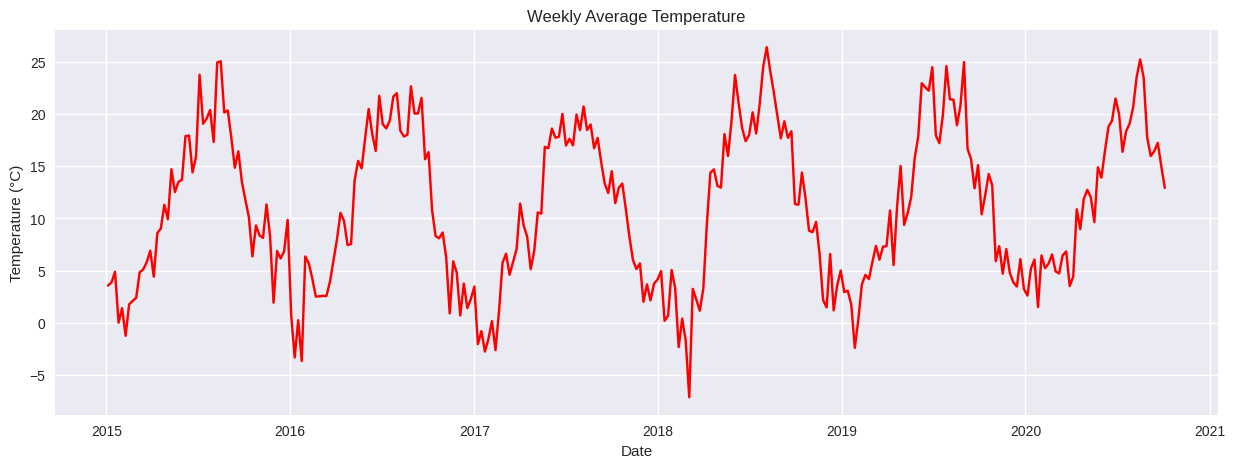

In [ ]:
# Cell 42: Weekly Average Temperature

plt.figure(figsize=(15,5))

plt.plot(
    weekly_temp.index,
    weekly_temp['temperature'],
    color='red'
)

plt.title("Weekly Average Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.show()

In [ ]:
# Cell 43: Merge Weekly Load and Temperature

merged_df = weekly_df.join(
    weekly_temp,
    how='inner'
)

print("Merged Dataset Shape:", merged_df.shape)

display(merged_df.head())

Merged Dataset Shape: (301, 2)


,load,temperature
timestamp,,
2015-01-04,47233.739583,3.575000
2015-01-11,56191.101190,3.885714
2015-01-18,57672.678571,4.900000
2015-01-25,58613.303571,0.028571
2015-02-01,58734.029762,1.414286


In [ ]:
# Cell 44: Train-Test Split for SARIMAX

train_size = int(len(merged_df)*0.80)

train_exog = merged_df.iloc[:train_size]

test_exog = merged_df.iloc[train_size:]

print("Training Samples:", len(train_exog))

print("Testing Samples:", len(test_exog))


Training Samples: 240
Testing Samples: 61


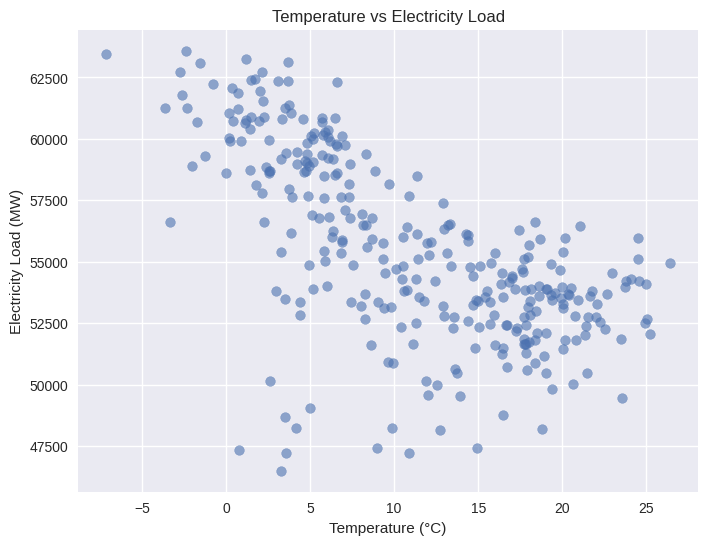

Correlation Matrix


,load,temperature
load,1.000000,-0.637664
temperature,-0.637664,1.000000


In [ ]:
# Cell 45: Relationship Between Temperature and Load

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df['temperature'],
    merged_df['load'],
    alpha=0.6
)

plt.title("Temperature vs Electricity Load")

plt.xlabel("Temperature (°C)")

plt.ylabel("Electricity Load (MW)")

plt.show()

print("Correlation Matrix")

display(merged_df.corr())

In [ ]:
# Cell 46: Train SARIMAX Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train_exog['load'],
    exog=train_exog[['temperature']],
    order=(1,1,1),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit()

print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                  240
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -2635.918
Date:                            Wed, 15 Jul 2026   AIC                           5283.836
Time:                                    22:10:00   BIC                           5301.178
Sample:                                01-04-2015   HQIC                          5290.883
                                     - 08-04-2019                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature  -107.5048         -0        inf      0.000    -107.505    -107.505
ar.L1          -0.0044         -

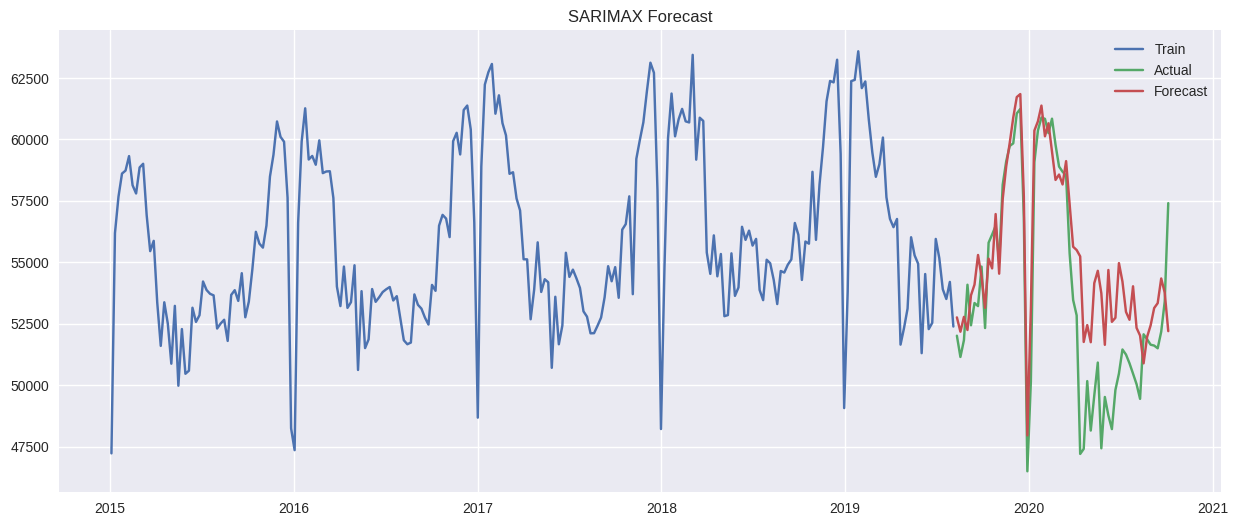

,predicted_mean
2019-08-11,52764.034804
2019-08-18,52182.030051
2019-08-25,52784.278527
2019-09-01,52250.908539
2019-09-08,53661.245301


In [ ]:
# Cell 47: Forecast with SARIMAX

sarimax_forecast = sarimax_fit.forecast(
    steps=len(test_exog),
    exog=test_exog[['temperature']]
)

plt.figure(figsize=(15,6))

plt.plot(train_exog.index, train_exog['load'], label='Train')

plt.plot(test_exog.index, test_exog['load'], label='Actual')

plt.plot(test_exog.index, sarimax_forecast, label='Forecast')

plt.title("SARIMAX Forecast")

plt.legend()

plt.show()

display(sarimax_forecast.head())

In [ ]:
# Cell 48: Evaluate SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    test_exog['load'],
    sarimax_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test_exog['load'],
        sarimax_forecast
    )
)

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 1905.164547711419
RMSE : 2543.0096082146943


In [ ]:
# Cell 49: Find Best SARIMAX Model using AIC

best_aic = np.inf

best_order = None

best_seasonal = None

for p in range(2):
    for d in range(2):
        for q in range(2):

            for P in range(2):
                for D in range(2):
                    for Q in range(2):

                        try:

                            model = SARIMAX(
                                train_exog['load'],
                                exog=train_exog[['temperature']],
                                order=(p,d,q),
                                seasonal_order=(P,D,Q,52),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            fit = model.fit(disp=False)

                            if fit.aic < best_aic:

                                best_aic = fit.aic

                                best_order = (p,d,q)

                                best_seasonal = (P,D,Q,52)

                        except:
                            continue

print("Best Order:", best_order)

print("Best Seasonal Order:", best_seasonal)

print("Best AIC:", best_aic)

Best Order: (1, 1, 1)
Best Seasonal Order: (1, 1, 0, 52)
Best AIC: 2356.943038767008


In [ ]:
# Cell 50: Train Final SARIMAX Model

final_sarimax = SARIMAX(
    train_exog['load'],
    exog=train_exog[['temperature']],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarimax_fit = final_sarimax.fit()

print(final_sarimax_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                load   No. Observations:                  240
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood               -1173.472
Date:                             Wed, 15 Jul 2026   AIC                           2356.943
Time:                                     22:25:36   BIC                           2371.432
Sample:                                 01-04-2015   HQIC                          2362.831
                                      - 08-04-2019                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature  -165.8262     38.786     -4.275      0.000    -241.845     -89.807
ar.L1           0.1956  

In [ ]:
# Cell 51: Forecast using Final SARIMAX

# Generate forecast using final SARIMAX model
final_forecast = final_sarimax_fit.forecast(
    steps=len(test_exog),
    exog=test_exog[['temperature']]
)

display(final_forecast.head())

,predicted_mean
2019-08-11,53105.972289
2019-08-18,52614.117355
2019-08-25,53285.140137
2019-09-01,52235.262442
2019-09-08,54195.696548


In [ ]:
# Cell 52: Evaluate Final SARIMAX Model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

final_mae = mean_absolute_error(
    test_exog['load'],
    final_forecast
)

final_rmse = np.sqrt(
    mean_squared_error(
        test_exog['load'],
        final_forecast
    )
)

print("Final SARIMAX MAE :", final_mae)

print("Final SARIMAX RMSE :", final_rmse)

Final SARIMAX MAE : 1957.6357458751675
Final SARIMAX RMSE : 2571.6001477432774


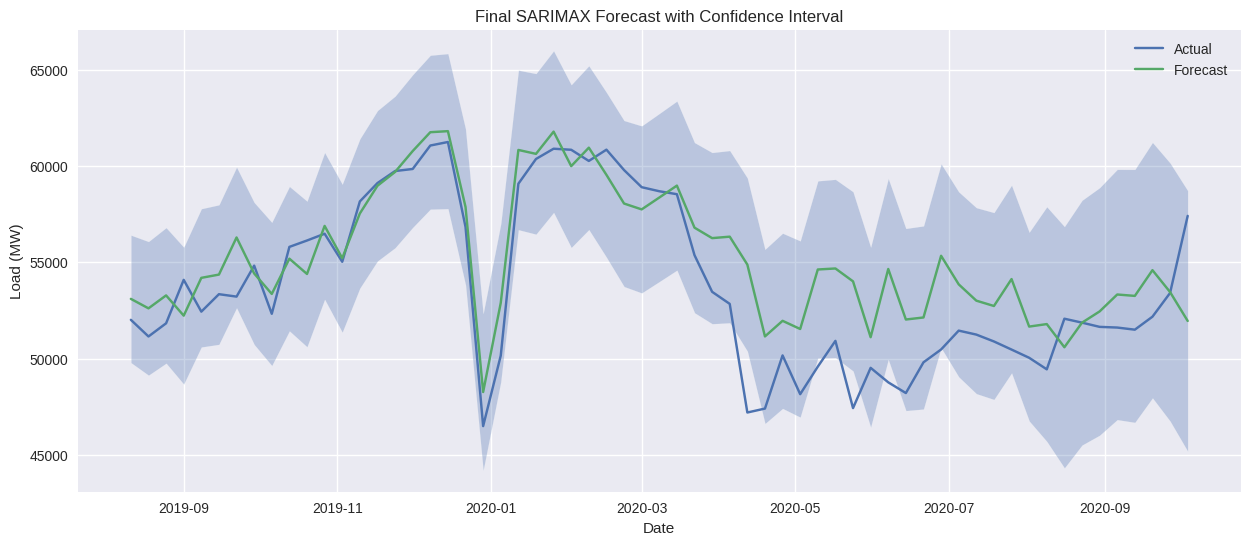

In [ ]:
# Cell 53: Forecast vs Actual with Confidence Intervals

forecast_result = final_sarimax_fit.get_forecast(
    steps=len(test_exog),
    exog=test_exog[['temperature']]
)

forecast_mean = forecast_result.predicted_mean

confidence_interval = forecast_result.conf_int()


plt.figure(figsize=(15,6))

plt.plot(
    test_exog.index,
    test_exog['load'],
    label="Actual"
)

plt.plot(
    test_exog.index,
    forecast_mean,
    label="Forecast"
)

plt.fill_between(
    test_exog.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3
)

plt.title("Final SARIMAX Forecast with Confidence Interval")

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.show()

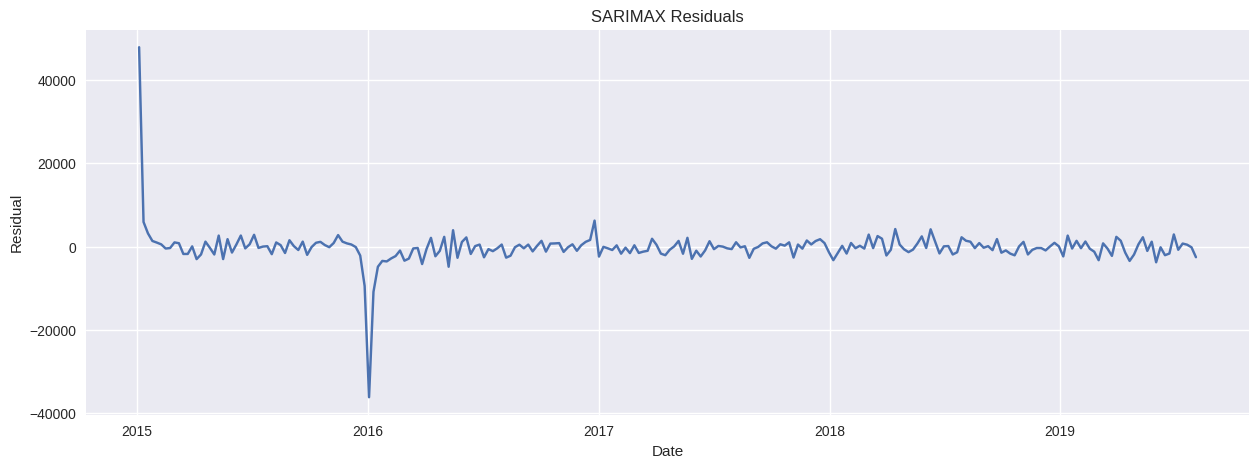

count      240.000000
mean      -225.605932
std       4337.088133
min     -36155.541444
25%      -1387.007196
50%       -182.212174
75%        835.772831
max      47826.568345
dtype: float64


In [ ]:
# Cell 54: Residual Diagnostics

residuals = final_sarimax_fit.resid


plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMAX Residuals")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.show()


print(residuals.describe())

In [ ]:
# Cell 55: Model Comparison

comparison = pd.DataFrame({
    'Model': [
        'Mean',
        'Naive',
        'Seasonal Naive',
        'Drift',
        'SARIMA',
        'SARIMAX'
    ],

    'RMSE': [
        results.loc[results['Model']=='Mean','RMSE'].values[0],
        results.loc[results['Model']=='Naive','RMSE'].values[0],
        results.loc[results['Model']=='Seasonal Naive','RMSE'].values[0],
        results.loc[results['Model']=='Drift','RMSE'].values[0],
        results.loc[results['Model']=='SARIMA','RMSE'].values[0],
        final_rmse
    ]
})


display(comparison.sort_values('RMSE'))

,Model,RMSE
5,SARIMAX,2571.600148
4,SARIMA,2613.567408
2,Seasonal Naive,3255.523670
3,Drift,4499.269103
1,Naive,4510.480290
0,Mean,4742.542591


In [ ]:
# Cell 56: Create Feature-Based Dataset

feature_df = merged_df.copy()


# Create time features

feature_df['year'] = feature_df.index.year

feature_df['month'] = feature_df.index.month

feature_df['week'] = feature_df.index.isocalendar().week.astype(int)


# Create lag features

feature_df['lag_1'] = feature_df['load'].shift(1)

feature_df['lag_52'] = feature_df['load'].shift(52)


display(feature_df.head())

,load,temperature,year,month,week,lag_1,lag_52
timestamp,,,,,,,
2015-01-04,47233.739583,3.575000,2015,1,1,NaN,NaN
2015-01-11,56191.101190,3.885714,2015,1,2,47233.739583,NaN
2015-01-18,57672.678571,4.900000,2015,1,3,56191.101190,NaN
2015-01-25,58613.303571,0.028571,2015,1,4,57672.678571,NaN
2015-02-01,58734.029762,1.414286,2015,2,5,58613.303571,NaN


In [ ]:
# Cell 57: Clean Feature Dataset

# Remove missing values caused by lag creation

feature_df = feature_df.dropna()


print("Dataset Shape:", feature_df.shape)

print("\nMissing Values:")

print(feature_df.isnull().sum())

display(feature_df.head())

Dataset Shape: (249, 7)

Missing Values:
load           0
temperature    0
year           0
month          0
week           0
lag_1          0
lag_52         0
dtype: int64


,load,temperature,year,month,week,lag_1,lag_52
timestamp,,,,,,,
2016-01-03,47364.035714,0.757143,2016,1,53,48253.363095,47233.739583
2016-01-10,56615.142857,-3.314286,2016,1,1,47364.035714,56191.101190
2016-01-17,59913.910714,0.257143,2016,1,2,56615.142857,57672.678571
2016-01-24,61267.529762,-3.642857,2016,1,3,59913.910714,58613.303571
2016-01-31,59185.089286,6.357143,2016,1,4,61267.529762,58734.029762


In [ ]:
# Cell 58: Train-Test Split for Feature-Based Models

X = feature_df.drop('load', axis=1)

y = feature_df['load']


train_size = int(len(feature_df)*0.80)


X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]


print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (199, 6)
Testing Data: (50, 6)


In [ ]:
# Cell 59: Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


rf_forecast = rf_model.predict(X_test)


display(rf_forecast[:5])

array([57925.86791667, 55670.64264881, 58550.48196429, 59635.77404762,
       58950.50220238])

In [ ]:
# Cell 60: Evaluate Random Forest

rf_mae = mean_absolute_error(
    y_test,
    rf_forecast
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_forecast
    )
)


print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 2238.531666269848
Random Forest RMSE: 3042.1943884423686


In [ ]:
# Cell 61: Train Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor


gb_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)


gb_model.fit(
    X_train,
    y_train
)


gb_forecast = gb_model.predict(X_test)


display(gb_forecast[:5])

array([57931.85169859, 55458.23088538, 58805.40251402, 59879.77284163,
       60806.67081995])

In [ ]:
# Cell 62: Evaluate Gradient Boosting

gb_mae = mean_absolute_error(
    y_test,
    gb_forecast
)


gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_forecast
    )
)


print("Gradient Boosting MAE:", gb_mae)

print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 2212.9116877777574
Gradient Boosting RMSE: 2948.594168078026


In [ ]:
# Cell 63: Forecast Comparison

ml_comparison = pd.DataFrame({

    'Model':[
        'SARIMAX',
        'Random Forest',
        'Gradient Boosting'
    ],

    'RMSE':[
        final_rmse,
        rf_rmse,
        gb_rmse
    ],

    'MAE':[
        final_mae,
        rf_mae,
        gb_mae
    ]
})


display(
    ml_comparison.sort_values('RMSE')
)

,Model,RMSE,MAE
0,SARIMAX,2571.600148,1957.635746
2,Gradient Boosting,2948.594168,2212.911688
1,Random Forest,3042.194388,2238.531666


In [ ]:
# Cell 64: Importing tensor flow

import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
# Cell 65: Prepare Hourly Data for LSTM

# Create hourly LSTM dataset

lstm_df = hourly_df.copy()

# Keep only load column
lstm_df = lstm_df[['load']]

print("Dataset Shape:", lstm_df.shape)

display(lstm_df.head())

Dataset Shape: (50400, 1)


,load
timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


In [ ]:
# Cell 66: Scale the Hourly Data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    lstm_df[['load']]
)

print("Scaled Data Shape:", scaled_data.shape)

display(scaled_data[:5])

Scaled Data Shape: (50400, 1)


array([[0.21288007],
       [0.1909087 ],
       [0.1686562 ],
       [0.16128195],
       [0.16508802]])

In [ ]:
# Cell 67: Create LSTM Sequences

def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data)-window_size):

        X.append(data[i:i+window_size])

        y.append(data[i+window_size])

    return np.array(X), np.array(y)


# Use previous 24 hours to predict next hour

window_size = 24


X, y = create_sequences(
    scaled_data,
    window_size
)


print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (50376, 24, 1)
y Shape: (50376, 1)


In [ ]:
# Cell 68: Train-Test Split for LSTM

train_size = int(len(X)*0.80)


X_train = X[:train_size]

X_test = X[train_size:]


y_train = y[:train_size]

y_test = y[train_size:]


print("Training X:", X_train.shape)

print("Testing X:", X_test.shape)

Training X: (40300, 24, 1)
Testing X: (10076, 24, 1)


In [ ]:
# Cell 69: Build LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


lstm_model = Sequential()


lstm_model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)


lstm_model.add(
    Dropout(0.2)
)


lstm_model.add(
    LSTM(50)
)


lstm_model.add(
    Dropout(0.2)
)


lstm_model.add(
    Dense(1)
)


lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 70: Train LSTM Model

history = lstm_model.fit(

    X_train,
    y_train,

    epochs=20,

    batch_size=32,

    validation_data=(
        X_test,
        y_test
    ),

    verbose=1
)

Epoch 1/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - loss: 0.0114 - val_loss: 0.0015
Epoch 2/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0030 - val_loss: 8.9616e-04
Epoch 3/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.0020 - val_loss: 9.3040e-04
Epoch 4/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0015 - val_loss: 6.4495e-04
Epoch 5/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0013 - val_loss: 8.6908e-04
Epoch 6/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0012 - val_loss: 6.9083e-04
Epoch 7/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0011 - val_loss: 6.6443e-04
Epoch 8/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0011 - val_loss: 6.2945e-04
Epoch 9/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0010 - val_loss: 6.4994e-04
Epoch 10/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0010 - val_loss: 5.4103e-04
Epoch 11/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss

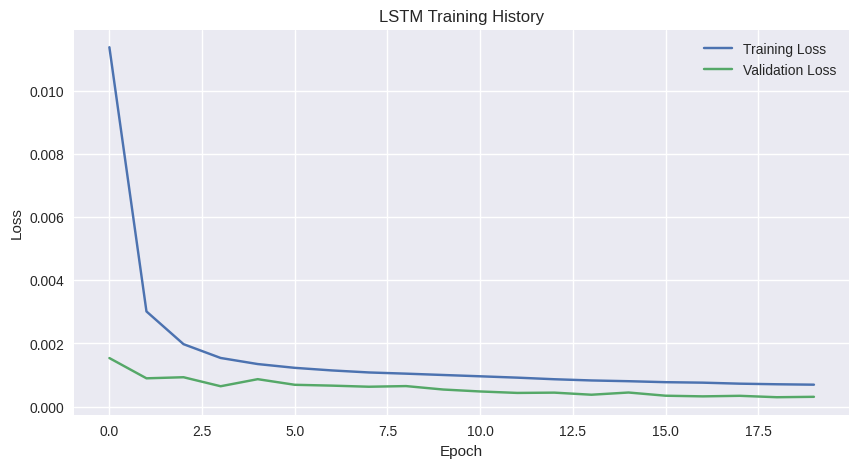

In [ ]:
# Cell 71: Plot Training History

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)


plt.title("LSTM Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
#  Cell 72: Generate LSTM Forecast

# Predict test data

lstm_predictions = lstm_model.predict(
    X_test
)


print("Prediction Shape:")

print(lstm_predictions.shape)


display(lstm_predictions[:5])

315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction Shape:
(10076, 1)


array([[0.43902856],
       [0.5620578 ],
       [0.6410829 ],
       [0.6630074 ],
       [0.68361396]], dtype=float32)

In [ ]:
# Cell 73: Convert Predictions Back to Original Scale

# Reverse scaling

lstm_predictions_original = scaler.inverse_transform(
    lstm_predictions
)


y_test_original = scaler.inverse_transform(
    y_test
)


display(
    lstm_predictions_original[:5]
)

array([[51608.562],
       [57297.68 ],
       [60951.953],
       [61965.785],
       [62918.68 ]], dtype=float32)

In [ ]:
# Cell 74: Evaluate LSTM Model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


lstm_mae = mean_absolute_error(
    y_test_original,
    lstm_predictions_original
)


lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        lstm_predictions_original
    )
)


print("LSTM MAE :", lstm_mae)

print("LSTM RMSE :", lstm_rmse)

LSTM MAE : 627.9192409174648
LSTM RMSE : 814.0295975533746


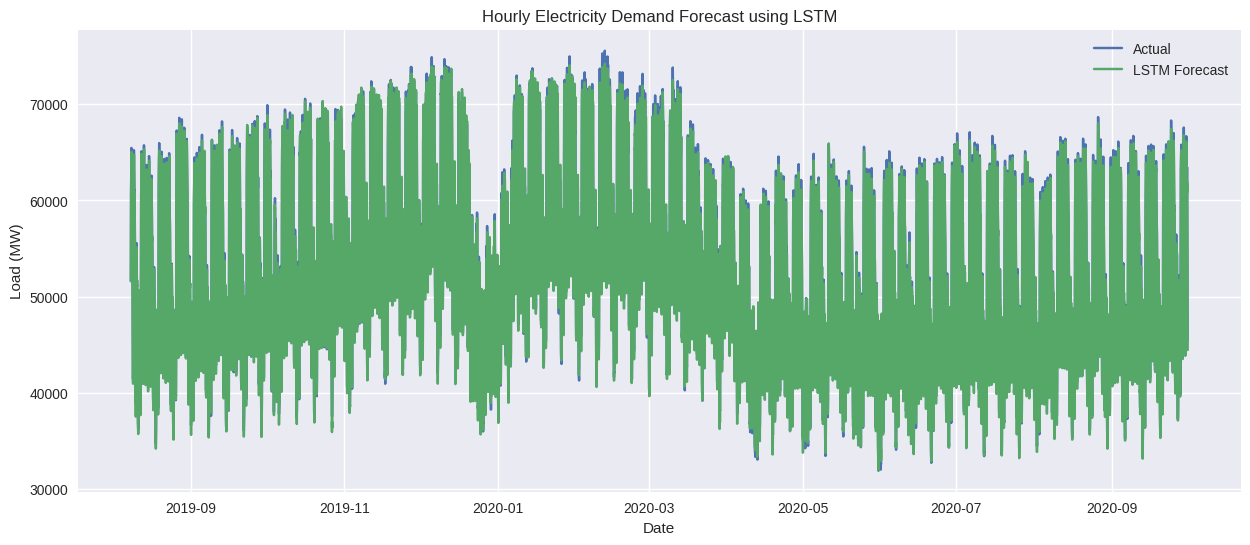

In [ ]:
# Cell 75: LSTM Forecast Plot

# Create time index for predictions
prediction_dates = lstm_df.index[-len(y_test_original):]

plt.figure(figsize=(15,6))

plt.plot(
    prediction_dates,
    y_test_original,
    label='Actual'
)

plt.plot(
    prediction_dates,
    lstm_predictions_original,
    label='LSTM Forecast'
)

plt.title(
    "Hourly Electricity Demand Forecast using LSTM"
)

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.show()